In [1]:
"""
Parameters variations between prior and posteriors
@V. Tartaglione/F. Maignan/L. Leverne/C. Abadie
"""
import pandas as pd
import os
import sys
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.cm as cm
import numpy as np
import math
from netCDF4 import Dataset 
import seaborn as sns
from datetime import datetime 

In [2]:
ibm_colors = [
        '#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000',
        '#009E73', '#56B4E9', '#E69F00', '#CC79A7', '#005AB5',
        '#F0E442', '#E6AB02', '#00A087', '#882255', '#AA4499'
    ]

In [3]:
data_file_configurations = [
    {
        'label': 'Post. SIF',
        'path': '/home/surface9/vtartagl/ASSIMS/ARTICLE_LEVERNE/SIF/OPTIM_SIF__GA__pft07__20gridcells__2019-2022__leverne_model__nokF-ASJ-ASV-EJMAX__GDD_TH_1.5__new_GC_distrib/output_20250803_213119.nc',
        'color': '#009E73', 
        'marker': '<',
        'size': 200
    },
        {
        'label': 'Post. GPP',
        'path': '/home/surface9/vtartagl/ASSIMS/ARTICLE_LEVERNE/GPP/OPTIM_GPP__GA__pft07__noEJMAX-LMAX__GDD_TH_1.5/output_20250803_212438.nc',
        'color': '#56B4E9', 
        'marker': '>',
        'size': 200
    },
    {
        'label': 'Post. SIF-GPP Leverne',
        'path': '/home/surface9/vtartagl/ASSIMS/ARTICLE_LEVERNE/SIF-GPP/OPTIM_SIF-GPP__GA__pft07__20gridcells__2019-2022__leverne_model__11sites__weight13.577_no_kF-EJMAX-LMAX__GDD_TH_1.5__new_GC_distrib/output_20250803_215037.nc',
        'color': '#CC79A7', 
        'marker': 'd',
        'size': 200
    },
    {
        'label': 'Post. SIF-GPP Bacour',
        'path': '/home/surface9/vtartagl/ASSIMS/ARTICLE_LEVERNE/SIF-GPP/OPTIM_SIF-GPP__GA__pft07__20gridcells__2019-2022__bacour_model__11sites__weight13.577_no_kF-EJMAX-LMAX__GDD_TH_1.5__new_GC_distrib/output_20250803_230925.nc',
        'color': '#882255', 
        'marker': 'd',
        'size': 150  
    }
]
prior_config = {
    'label': 'Prior',
    'color': '#E69F00', 
    'marker': 'v',
    'size': 200
}

In [4]:
# --- Read Base Data (Parameters, Prior, Min, Max) ---
if not data_file_configurations:
    raise ValueError("data_file_configurations list cannot be empty.")
base_file_path = data_file_configurations[2]['path'] # Correspond to SIF-GPP Leverne assim with full set of parameter

In [5]:
nc_fid_base = Dataset(base_file_path, 'r')
param_id_base = nc_fid_base.variables['param_id'][:]
prior_base = nc_fid_base.variables['param_prior'][:]
mini_base = nc_fid_base.variables['param_min'][:]
maxi_base = nc_fid_base.variables['param_max'][:]
nc_fid_base.close()

In [6]:
df_main = pd.DataFrame({
    'Parameters': np.ma.getdata(param_id_base),
    'Prior': np.ma.getdata(prior_base),
    'Min': np.ma.getdata(mini_base),
    'Max': np.ma.getdata(maxi_base)
})

In [7]:
# --- Read and Merge Posterior Data for all configured files ---
for config in data_file_configurations:
    nc_fid_post = Dataset(config['path'], 'r')
    current_param_id = np.ma.getdata(nc_fid_post.variables['param_id'][:])
    post_values = nc_fid_post.variables['param'][:][-1, :] # Last iteration
    nc_fid_post.close()
    
    post_col_name = config['label'].replace(' ', '_').replace('.', '').replace('-', '_')

    temp_df = pd.DataFrame({
        'Parameters': current_param_id,
        post_col_name: np.ma.getdata(post_values)
    })
    df_main = pd.merge(df_main, temp_df, on='Parameters', how='left')

In [8]:
# --- Replace parameter names (human-readable) ---
"""param_name_replacements = {
    'ALA__06': 'ALA', 'k_F__06': 'kF', 'a_psII': 'apsII',
    'VCMAX25__06': 'VCMAX25', 'LEAFAGECRIT__06': 'LEAFAGECRIT',
     'ASJ__06': 'ASJ', 'ASV__06': 'ASV',
    'ARJV__06': 'ARJV', 'SLA__06': 'SLA', 'CLUMPING__06': 'CLUMPING',
    'LAI_MAX__06': 'LAI_MAX', 'KMC25__06': 'KMC25', 'GDDNCD_CURVE__06': 'GDDNCD_CURVE', 
    'GDDNCD_REF__06':'GDDNCD_REF', 'LAI_MAX_TO_HAPPY__06': 'LAI_MAX_TO_HAPPY', 'SOIL_Q10': 'SOILQ10', 'MOISTCONT_MIN': 'MOISTCONT_MIN', 'MAINT_RESP_SLOPE_C': 'MAINT_RESP_SLOPE_C', 'MAINT_RESP_SLOPE_C__06': 'MAINT_RESP_SLOPE_C'
}"""
param_name_replacements = {
    'ALA__07': 'ALA', 'a_psII': 'apsII',
    'p1_NPQ_reversible': 'p1_NPQr', 'p2_NPQ_reversible': 'p2_NPQr',
    'VCMAX25__07': 'VCMAX25', 'LEAFAGECRIT__07': 'LEAFAGECRIT',
    'E_JMAX__07': 'E_JMAX', 'ASJ__07': 'ASJ', 'ASV__07': 'ASV',
    'ARJV__07': 'ARJV', 'SLA__07': 'SLA', 'CLUMPING__07': 'CLUMPING',
    'LAI_MAX__07': 'LAI_MAX'
}
# Apply replacements if 'Parameters' column is object/string type
if df_main['Parameters'].dtype == 'object':
    df_main['Parameters'] = df_main['Parameters'].str.decode('utf-8').str.strip() if isinstance(df_main['Parameters'].iloc[0], bytes) else df_main['Parameters'].str.strip()

In [9]:
df_main['Parameters'] = df_main['Parameters'].replace(param_name_replacements)

In [10]:
# --- Set parameter order for plotting ---
parameter_order = [
    'ALA', 'CLUMPING', 'apsII', 'p1_NPQr', 'p2_NPQr',
    'VCMAX25', 'LEAFAGECRIT', 'ASJ', 'ASV',
    'ARJV', 'SLA', 'LAI_MAX', 'KMC25', 'GDDNCD_CURVE', 
    'GDDNCD_REF', 'LAI_MAX_TO_HAPPY', 'SOIL_Q10', 'KSOILC', 'MOISTCONT_MIN', 'MAINT_RESP_SLOPE_C'
]
df_main['Parameters'] = pd.Categorical(df_main['Parameters'], categories=parameter_order, ordered=True)
df_main = df_main.sort_values('Parameters').reset_index(drop=True)

In [11]:
# --- Calculate normalized values ---
df_main['norma_Prior'] = (df_main['Prior'] - df_main['Min']) / (df_main['Max'] - df_main['Min'])

In [12]:
for config in data_file_configurations:
    post_col_name = config['label'].replace(' ', '_').replace('.', '').replace('-', '_')
    norma_col_name = 'norma_' + post_col_name
    if post_col_name in df_main.columns:
        df_main[norma_col_name] = (df_main[post_col_name] - df_main['Min']) / (df_main['Max'] - df_main['Min'])
    else:
        print(f"Warning: Column {post_col_name} not found in df_main for normalization.")

In [13]:
# --- Create DataFrame for plotting (long format) ---
plotting_data_frames = []

In [14]:
# Add Prior data
if 'norma_Prior' in df_main.columns:
    plotting_data_frames.append(pd.DataFrame({
        'parametres': df_main['Parameters'],
        'value': df_main['norma_Prior'],
        'type': prior_config['label']
    }))

In [15]:
# Add Posterior data from each configuration
for config in data_file_configurations:
    norma_col_name = 'norma_' + config['label'].replace(' ', '_').replace('.', '').replace('-', '_')
    if norma_col_name in df_main.columns:
        plotting_data_frames.append(pd.DataFrame({
            'parametres': df_main['Parameters'],
            'value': df_main[norma_col_name],
            'type': config['label']
        }))
    else:
        print(f"Warning: Normalized column {norma_col_name} not found for plotting.")

In [16]:
if not plotting_data_frames:
    raise ValueError("No data available for plotting. Check configurations and file processing.")
final_plot_df = pd.concat(plotting_data_frames).reset_index(drop=True)

In [17]:
# --- Map parameter names to LaTeX format for plot labels ---
name_ORC_map = {
    'ASV': r'$a_{S,V}$', 'ASJ': r'$a_{S,J}$', 'VCMAX25': r'$V_{\mathrm{cmax},25}$',
    'E_JMAX': r'$E_{J\mathrm{max}}$', 'SLA': r'$SLA$', 'LEAFAGECRIT': r'$L_{agecrit}$',
    'ARJV': r'$a_{R,JV}$', 'ALA': r'$ALA$', 'CLUMPING': r'$CI$', 'kF': r'$k_{F}$',
    'apsII': r'$a_{PSII}$', 'p1_NPQr': r'$p1_{NPQr}$', 'p2_NPQr': r'$p2_{NPQr}$',
    'LAI_MAX': r'$LAI_{\mathrm{max}}$'
}
final_plot_df['id_plot'] = final_plot_df['parametres'].astype(str).map(name_ORC_map).fillna(final_plot_df['parametres'].astype(str))
final_plot_df['id_plot'] = pd.Categorical(final_plot_df['id_plot'], categories=[name_ORC_map.get(p, p) for p in parameter_order], ordered=True)
# Sort by id_plot primarily to ensure y-axis order, then by type if needed for consistent processing by seaborn
final_plot_df = final_plot_df.sort_values(by=['id_plot', 'type'])

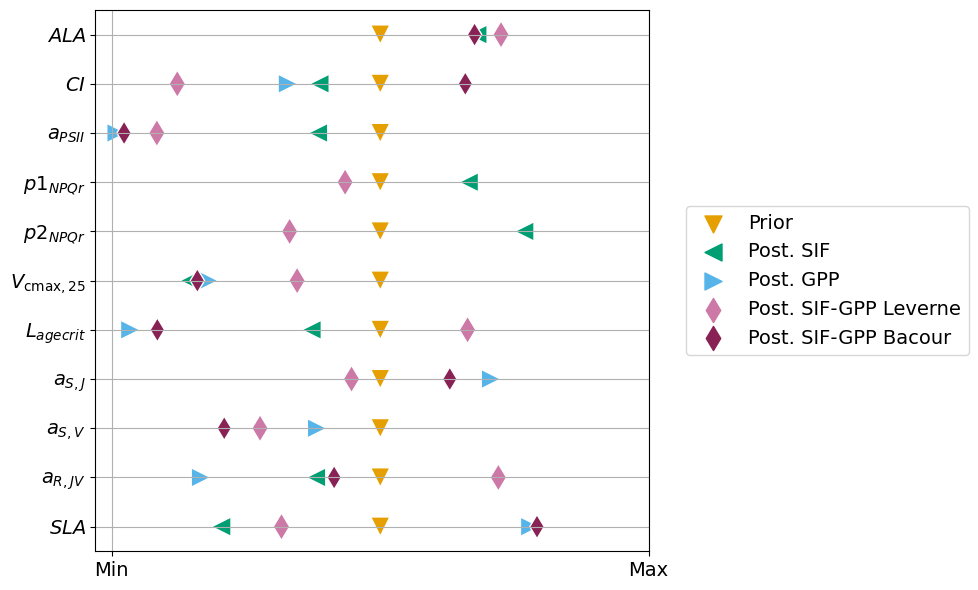

In [18]:
# --- Create Plot ---
fontsize_title = 18
fontsize_label = 14
fontsize_legend = 14

plt.figure(figsize=(10, 6))
ax = plt.gca()

special_type_label = 'Post. SIF-GPP Bacour' 
special_config = next((cfg for cfg in data_file_configurations if cfg['label'] == special_type_label), None)

other_configs = [prior_config] + [cfg for cfg in data_file_configurations if cfg['label'] != special_type_label]
other_data_to_plot = final_plot_df[final_plot_df['type'] != special_type_label]

other_palette_map = {cfg['label']: cfg['color'] for cfg in other_configs}
other_markers_map = {cfg['label']: cfg['marker'] for cfg in other_configs}

# Plot "other" types
g = sns.scatterplot(
    x="value",
    y="id_plot",
    hue="type",
    hue_order=[cfg['label'] for cfg in other_configs], # Maintain order for legend consistency
    palette=other_palette_map,
    style="type",
    style_order=[cfg['label'] for cfg in other_configs], # Maintain order
    markers=other_markers_map,
    s=200, 
    data=other_data_to_plot,
    ax=ax
)

# Plot "special" type (e.g., Bacour)
if special_config and not final_plot_df[final_plot_df['type'] == special_type_label].empty:
    special_data_to_plot = final_plot_df[final_plot_df['type'] == special_type_label]
    sns.scatterplot(
        x="value",
        y="id_plot",
        hue="type",
        hue_order=[special_config['label']],
        palette={special_config['label']: special_config['color']},
        style="type",
        style_order=[special_config['label']],
        markers={special_config['label']: special_config['marker']},
        s=special_config['size'],
        data=special_data_to_plot,
        ax=g,
        legend=True # Add to legend items
    )

g.set_ylabel("")
g.set_xlabel("")
g.set_xticks([0, 1])
g.set_xticklabels(["Min", "Max"], fontsize=fontsize_label)
g.axes.yaxis.set_tick_params(labelsize=fontsize_label)
plt.grid()

# --- Create a custom legend ---
handles, labels = g.get_legend_handles_labels()
desired_legend_order = [prior_config['label']] + [cfg['label'] for cfg in data_file_configurations]

unique_handles_map = {}
# Store handles by label, last one wins if duplicates (seaborn might make multiple for same label if style/hue vary)
# However, with hue="type" and style="type", this should be one handle per type.
for handle, label in zip(handles, labels):
    unique_handles_map[label] = handle

ordered_handles = [unique_handles_map[lbl] for lbl in desired_legend_order if lbl in unique_handles_map]
ordered_labels = [lbl for lbl in desired_legend_order if lbl in unique_handles_map]

if g.legend_ is not None:
    g.legend_.remove()
legend = g.legend(ordered_handles, ordered_labels, loc='center left', bbox_to_anchor=(1.05, 0.5), prop={'size': fontsize_legend})

for h_legend in legend.legend_handles:
    h_legend.set_sizes([150])
    
plt.tight_layout()
plt.show(block=False)
#plt.savefig('./PNG/Figure3.png', 
#                dpi=300, bbox_inches='tight')